# Korrelation zwischen Alphabetisierungsrate und BIP pro Kopf

## Gruppe: 
Lia Bütikofer (buetilia@students.zhaw.ch), Vanessa Cakoncev (cakonvan@students.zhaw.ch), Lilia Totila (totillil@students.zhaw.ch)

## Fragestellung
Besteht ein Zusammenhang zwischen dem Bruttoinlandsprodukt (BIP) pro Kopf und der Analphabetisierungsrate, und wie zeigt sich dieser Zusammenhang weltweit, sowie in ausgewählten Ländern?

## Quellen
https://ourworldindata.org/grapher/literacy-rate-vs-gdp-per-capita


## 1. Daten beschaffen und laden

In [84]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. KONFIGURATION ---
file_path = "literacy-rate-vs-gdp-per-capita.csv"
start_year = 1990
end_year = 2023
target_countries = ['Afghanistan', 'Sudan', 'Syria', 'Iraq'] 
pd.set_option('display.max_rows', 10) # Setzt die maximale Zeilenanzahl für eine übersichtlichere Ausgabe

# --- 2. DATEN LADEN & GLOBALE FILTERUNG ---

try:
    df_rohdaten = pd.read_csv(file_path)
except FileNotFoundError:
    print("FATALER FEHLER: Die Datei 'literacy-rate-vs-gdp-per-capita.csv' wurde nicht gefunden.")
    print("Bitte stellen Sie sicher, dass die Datei im selben Verzeichnis wie das Notebook liegt.")
    exit()

# Sicherstellen, dass die Spalte 'Year' numerisch ist
df_rohdaten['Year'] = pd.to_numeric(df_rohdaten['Year'], errors='coerce')

# Global gefilterter DataFrame (Weltweit, 1990-2023)
df_global_filtered = df_rohdaten[
    (df_rohdaten['Year'] >= start_year) & 
    (df_rohdaten['Year'] <= end_year)
].copy()

# --- 3. SPALTEN UMBENENNEN & VORBEREITUNG ---

df_global_filtered.rename(columns={
    'Entity': 'Land',
    'Year': 'Jahr',
    'Literacy rate among adults': 'Alphabetisierungsrate',
    'GDP per capita, PPP (constant 2021 international $)': 'BIP pro Kopf'
}, inplace=True)

# Spezifischer DataFrame für die 4 Zielländer
df_zielgruppe = df_global_filtered[df_global_filtered['Land'].isin(target_countries)].copy()
df_zielgruppe['Analphabetisierungsrate (%)'] = 100 - df_zielgruppe['Alphabetisierungsrate']


print("--- ✅ BASIS-DATENFRAMES ERSTELLT ---")
print("Für globale Analysen: df_global_filtered")
print("Für Länderspezifische Analysen: df_zielgruppe")

--- ✅ BASIS-DATENFRAMES ERSTELLT ---
Für globale Analysen: df_global_filtered
Für Länderspezifische Analysen: df_zielgruppe


In [111]:
df = pd.read_csv("literacy-rate-adults.csv")
df_gdp = pd.read_csv("literacy-rate-vs-gdp-per-capita.csv")
df.head()

,Entity,Code,Year,"Literacy rate, adult total (% of people ages 15 and above)"
0,Afghanistan,AFG,1979,18.00000
1,Afghanistan,AFG,2011,31.00000
2,Afghanistan,AFG,2015,33.75384
3,Afghanistan,AFG,2021,37.00000
4,Albania,ALB,2001,99.00000


In [87]:
import pandas as pd

# Laden der Haupt-Quelldatei
df_rohdaten = pd.read_csv("literacy-rate-vs-gdp-per-capita.csv")

# Korrekte Zählung: 'Entity' ist der Name der Länder-Spalte in der Rohdatei.
anzahl_laender = df_rohdaten["Entity"].nunique()

# Ausgabe der Zählung
print("Anzahl verschiedener Länder:", anzahl_laender)

Anzahl verschiedener Länder: 310


In [88]:
df["Entity"].value_counts().head(10)

Entity
Latin America and Caribbean (WB)                            50
Middle East, North Africa, Afghanistan and Pakistan (WB)    50
Lower-middle-income countries                               49
South Asia (WB)                                             49
East Asia and Pacific (WB)                                  48
World                                                       48
Upper-middle-income countries                               48
Sub-Saharan Africa (WB)                                     39
Low-income countries                                        36
Europe and Central Asia (WB)                                30
Name: count, dtype: int64

In [89]:
## Analyse der Jahre

In [90]:
print("\n--- 2.2 Zeitspanne des gefilterten Datensatzes ---")
print(f"Erstes Jahr: {df_gefiltert['Jahr'].min()}")
print(f"Letztes Jahr: {df_gefiltert['Jahr'].max()}")


--- 2.2 Zeitspanne des gefilterten Datensatzes ---
Erstes Jahr: 1990
Letztes Jahr: 2023


In [91]:
print("\n--- 2.3 Jährliche Datenabdeckung (Häufigkeit pro Jahr) ---")
print("Anzahl der Zeilen pro Jahr in den 4 Zielländern:")

# df_gefiltert["Jahr"].value_counts().sort_index().head(10)
jahres_verteilung = df_gefiltert["Jahr"].value_counts().sort_index().head(10)
print(jahres_verteilung.to_markdown())


--- 2.3 Jährliche Datenabdeckung (Häufigkeit pro Jahr) ---
Anzahl der Zeilen pro Jahr in den 4 Zielländern:
|   Jahr |   count |
|-------:|--------:|
|   1990 |     281 |
|   1991 |     277 |
|   1992 |     276 |
|   1993 |     275 |
|   1994 |     274 |
|   1995 |     274 |
|   1996 |     274 |
|   1997 |     274 |
|   1998 |     274 |
|   1999 |     274 |


## 2. Daten vorbereiten 
- Die Roh-Daten sind bereits im Long-Format
- Für die Analyse werden die Daten pivotiert: Jede Spalte repräsentiert eine Region, die Zeilen sind die verschiedenen Jahre - in absteigender Reihenfolge.

In [92]:
df.columns

Index(['Entity', 'Code', 'Year',
       'Literacy rate, adult total (% of people ages 15 and above)'],
      dtype='object')

In [93]:
df_filtered = df[(df["Year"] >= 1985) & (df["Year"] <= 2025)]
df_filtered.head()

,Entity,Code,Year,"Literacy rate, adult total (% of people ages 15 and above)"
1,Afghanistan,AFG,2011,31.00000
2,Afghanistan,AFG,2015,33.75384
3,Afghanistan,AFG,2021,37.00000
4,Albania,ALB,2001,99.00000
5,Albania,ALB,2008,96.00000


## 3. Statistik der Roh-Daten (Analyse im Long-Format)

über die einzelnen Spalten kann folgendes ausgesagt werden:
- Die Spalte *Gebiete* enthält 261 verschieden Gebiete
- Die Spalte *Codes* enthält 239 verschiedene Codes
- Es sind Daten zwischen 1543 and 2021 vorhanden. Ab dem Jahr 1950 sind die Daten komplett
- Die Lebenserwartung streut zwischen 12 und 86.5 Jahren

In [105]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1528 entries, 0 to 1527
Data columns (total 4 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   Entity                                                      1528 non-null   object 
 1   Code                                                        1117 non-null   object 
 2   Year                                                        1528 non-null   int64  
 3   Literacy rate, adult total (% of people ages 15 and above)  1528 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 47.9+ KB


Index(['Entity', 'Code', 'Year',
       'Literacy rate, adult total (% of people ages 15 and above)'],
      dtype='object')

### 3.1 Analyse Gebiete

In [95]:
print('Anzahl verschiedener Gebiete: ', len(df['Entity'].unique()))

Anzahl verschiedener Gebiete:  179


In [106]:
# Anzahl Datenpunkte pro Gebiet
df['Entity'].value_counts()

Entity
Latin America and Caribbean (WB)                            50
Middle East, North Africa, Afghanistan and Pakistan (WB)    50
Lower-middle-income countries                               49
South Asia (WB)                                             49
East Asia and Pacific (WB)                                  48
                                                            ..
Kiribati                                                     1
Marshall Islands                                             1
Israel                                                       1
Solomon Islands                                              1
San Marino                                                   1
Name: count, Length: 179, dtype: int64

<Axes: title={'center': 'Anzahl Datenpunkte pro Gebiet'}, xlabel='Entity', ylabel='Anzahl Datenpunkte'>

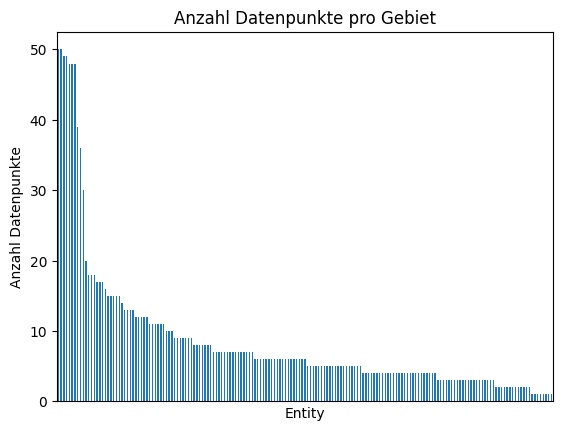

In [109]:
df['Entity'].value_counts().plot(kind='bar', 
                                 xticks=[],     # disable labels on x-axis
                                 ylabel='Anzahl Datenpunkte', title='Anzahl Datenpunkte pro Gebiet')

### 3.2 Analyse Codes

In [98]:
print('Anzahl verschiedener Codes: ', len(df['Code'].unique()))

Anzahl verschiedener Codes:  170


In [99]:
# Anzahl Datenpunkte pro Gebiet
df['Code'].value_counts()

Code
OWID_WRL    48
MEX         20
PSE         18
TUR         18
URY         18
            ..
JAM          1
MHL          1
KIR          1
SMR          1
SLB          1
Name: count, Length: 169, dtype: int64

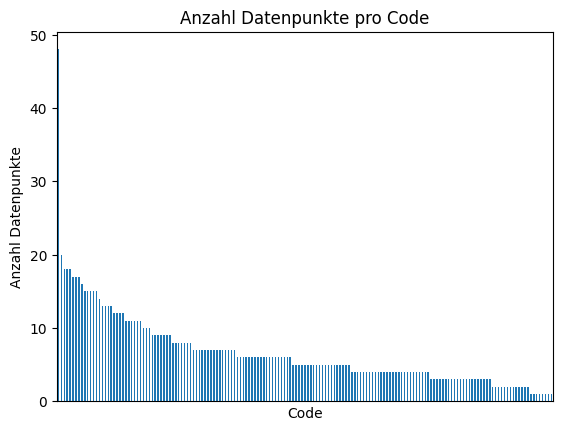

In [100]:
df['Code'].value_counts().plot(kind='bar',xticks=[], ylabel='Anzahl Datenpunkte', title='Anzahl Datenpunkte pro Code');

### 3.3 Analyse Jahr

In [101]:
print('Anzahl verschiedener Jahre: ', len(df['Jahr'].unique()))

KeyError: 'Jahr'

In [ ]:
# Anzahl Datenpunkte pro Jahr
df['Jahr'].value_counts().sort_index()

In [ ]:
# Jahre mit maximaler Anzahl Datenpunkte (257)
g = df['Jahr'].value_counts().sort_index().plot(ylabel='Anzahl Datenpunkte', title='Anzahl Datenpunkte pro Jahr');
g.axvline(x=1950, color='red',label='1950') # rote Linie bei 1950 - ab hier sind alle Jahre enthalten
g.legend()  # Legende anzeigen

### 3.4 Analyse Lebenserwartung

In [ ]:
df.describe()

In [ ]:
g = df['Lebenserwartung'].plot(kind='hist', bins=20, title='Histogramm der Lebenserwartung', 
                           xlabel='Lebenserwartung', ylabel='Anzahl Datenpunkte')
mean = df['Lebenserwartung'].mean()
g.axvline(x=df['Lebenserwartung'].mean(), color='red',label=f'Mittelwert = {mean:.2f}')  # rote Linie bei Mittelwert

median = df['Lebenserwartung'].median()
g.axvline(x=df['Lebenserwartung'].median(), color='orange',label=  f'Median = {median:.2f}')  # orange Linie bei Median

g.legend()




## 4. Analyse 

### Vorgehen

### Beobachtungen
- Afrikanische Länder sind an der Spitze in der Zunahme der Lebenserwartung. Eine Zunahme der Lebenserwartung von mehr als 5 Jahren haben: Uganda, Tanzania, Malawi, Zimbabwe, Lesotho, Swasiland
- Eine Reduktion der Lebenserwartung von mehr als 4 Jahren haben: Saint Vincent and the Grenadines, Mexiko, Kuba, Oman


### Interpretation

Corona führte bei allen Ländern zu einer Reduktion der Lebenserwartung (siehe Plot)

Länder (in Afrika) mit starker Zunahme der Lebensqualität:
- Bei den afrikanischen Ländern stieg die Lebenserwartung in den letzten Jahren sehr stark, da die Lebenserwartung sehr tief war. Zudem ist der Effekt von Corona auf die Lebenserwartung in den afrikanischen Ländern eher kleiner weil die Bevölkerung jünger ist
- Bei einigen afrikanischen Ländern hat sich die Lebenserwartung zwischen 1990 und 2000 stark verringert wegen HIV. Siehe Beispielsweise: https://life4me.plus/pl/news/life-expectancy-in-zimbabwe-shoots-up-hiv-infection-drop/


Länder mit einer starken Reduktion der Lebensqualität:
- Hier war die Lebenserwartung in den Jahren vor Corona konstant. Corona führte dann zu einer Reduktion der Lebenserwartung


### Berechnungen

In [ ]:
diffs = df_pivot[2021]-df_pivot[2011]   # Differenz zwischen 2021 und 2011
diffs = diffs.sort_values().dropna()  # sortieren nach Differenz und NaN-Werte entfernen
diffs

In [ ]:
diff_sel = (diffs < -4) | (diffs > 5)  # Auswahl der grössten und kleinsten Differenzen
diffs[diff_sel].plot(kind='barh', title='Grösste und kleinste Differenzen der Lebenserwartung 2011-2021')

In [ ]:
Gebiets_liste = diffs[diff_sel].index.tolist()  # Liste der Gebiete mit grössten und kleinsten Differenzen
print(Gebiets_liste)

### Visualisierung

In [ ]:
color_dict = {
    'Saint Vincent and the Grenadines': 'blue',
    'Mexico': 'cyan',
    'Cuba': 'lightgreen',
    'Oman': 'green',
    'Tanzania': 'red',
    'Sierra Leone': 'orange',
    'Malawi': 'yellow',
    'Zimbabwe': 'brown',
    'Lesotho': 'pink',
    'Eswatini': 'purple'
}

for gebiet in Gebiets_liste:
    diff = diffs[gebiet]
    g = df_pivot.loc[gebiet].plot(title='Lebenserwartungen', xlabel='Jahr', ylabel=f'Lebenserwartung', legend=True,
                                  label=f'{gebiet} - Diff. 2021-2011: {diff:.2f}', # für die Legende
                                  xlim=[1980,2025], ylim=[0,80],   # x- und y-Achsen begrenzen
                                  color=color_dict[gebiet],        # Farbe aus color_dict
                                  figsize=(7,7))                   # Grösse des Plots

# Covid Pandemie    
g.axvline(x=2020, color='black', linestyle='--') 
g.text(2020.5, 37, 'Covid')  

# HIV Pandemie
g.axvline(x=2005, color='black', linestyle='--')  
g.text(2005.5, 37, 'HIV');